# Node and layer eigenvector centralities for multiplex networks

Установка необходимых библиотек для визуализации графов

In [50]:
!pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 56.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
import csv
import pandas as pd
import time
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
from datetime import datetime
import matplotlib.colors as colors
import networkx as nx

In [51]:
from pyvis.network import Network
from IPython.display import IFrame

# Вспомогательные функции
Ниже реализованы функции для поиска собственного вектора, отвечающего максимальному собственному значению, а также генерация случайного тензора смежности

In [3]:
# find spectral radius and eigenvector
def max_eigenvector(matrix):
    eigenvalues, eigenvectors = np.linalg.eig(matrix)
    max_index = np.argmax(eigenvalues)
    result = abs(eigenvectors[:, max_index])
    return result


# generate random symmetric matrix
def generate_symmetric_matrix(n, k):
    matrix = np.random.randint(0, 50, (n, n))
    matrix = (matrix + matrix.T) // 2
    # add k zeros
    for _ in range(int(k * n * n // 2)):
        while True:
            i = random.randint(0, n - 1)
            j = random.randint(0, n - 1)
            if matrix[i][j] != 0 and i != j:
                matrix[i][j] = 0
                matrix[j][i] = 0
                break
    return matrix


def generate_random_tensor(n, L, k):
    tensor = np.zeros((n, n, L))
    for i in range(L):
        tensor[:, :, i] = generate_symmetric_matrix(n, k)
    return tensor


def generate_equal_layer_tensor(n, L, k):
    tensor = np.zeros((n, n, L))
    layer = generate_symmetric_matrix(n, k)
    for i in range(L):
        tensor[:, :, i] = layer
    return tensor


def print_tensor(tensor):
    L = np.size(tensor, 2)
    for l in range(L):
      print(tensor[:, :, l], end='\n\n')

# agg_deg и agg_eig
Функции ниже реализуют соответственно agg_deg и agg_eig. Рейтинг agg_deg - сумма всех степеней вершины во всех слоях, agg_eig - соответствующая координата собственного вектора.

In [5]:
def make_agg(n, L, tensor):
    Q = np.zeros((n, n))
    for l in range(L):
        Q += tensor[:, :, l]
    Q /= np.sum(Q)
    return Q


def agg_deg(Q, i):
    s = 0
    for j in range(np.size(Q, 0)):
        s += Q[i][j]
    return s


def agg_eig(Q, i):
    v = max_eigenvector(Q)
    return v[i] / np.linalg.norm(v, ord=1)

# eig_cen
Функции ниже реализуют eig_cen - рейтинг вершины получается нахождением собственного вектора для матрицы смежности каждого слоя. Рейтинг $i$ вершины получается как $(Q\mathbf{1})_i$

In [6]:
def make_q(n, L, tensor):
    Q = np.zeros((n, L))
    for l in range(L):
        layer = tensor[:, :, l]
        eigenvector = max_eigenvector(layer)
        Q[:, l] = eigenvector
    Q /= np.sum(Q)
    return Q


# eig_cen measure
def eig_cen(Q, i):
    s = 0
    for j in range(np.size(Q, 1)):
        s += Q[i][j]
    return s

# f-eigenvector centrality
Ниже реализована f-eigenvector centrality. Рейтинг вершины (и слоя) - соответствующая координата неподвижной точки функции $g$. Параметры $\alpha, \beta > 0$ могут варьироваться, но для сходимости требуется условие $2/\beta < (\alpha - 1)$. При этом увеличение $\alpha$ при фиксированном $\beta$ ускоряет сходимость.

In [8]:
alpha = 5
beta = 2


def f1(A, x, t):
    res = np.einsum('ijl,j,l->i', A, x, t)
    return res**(1 / alpha)


def f2(A, x, t):
    res = np.einsum('ijl,i,j->l', A, x, x)
    return res**(1 / beta)


def f(A, x, t):
    return f1(A, x, t), f2(A, x, t)


def g(A, x, t):
    f1_ = f1(A, x, t)
    f2_ = f2(A, x, t)
    f1_norm = np.linalg.norm(f1_, ord=1)
    f2_norm = np.linalg.norm(f2_, ord=1)
    return f1_ / f1_norm, f2_ / f2_norm

Функция ниже непосредственно реализует метод простых итерация для нахождения приближения для неподвижной точки.

In [11]:
def cf(A, x0, t0, k=5):
    res = (x0, t0)
    total_time = 0
    for i in range(k):
        start_time = time.time()
        res1 = g(A, res[0], res[1])
        res = res1
        end_time = time.time()
        execution_time = end_time - start_time
        total_time += execution_time
        print(f"Время выполнения итерации {i}: {execution_time:.6f} секунд")
    average_time = total_time / k
    print(f"Среднее время одной итерации: {average_time:.6f}")
    return res

# Сравнение, графики
Код ниже реализует сравнение всех мер. Можно варьировать параметры $n, L, k$ - количество вершин, слоёв и долю нулей в каждом слое. Так же можно варьировать количество итераций (в статье есть оценки для числа итераций, необходимых для заданной точности)

Время выполнения итерации 0: 0.001071 секунд
Время выполнения итерации 1: 0.002010 секунд
Время выполнения итерации 2: 0.000755 секунд
Время выполнения итерации 3: 0.000924 секунд
Время выполнения итерации 4: 0.000654 секунд
Время выполнения итерации 5: 0.000571 секунд
Время выполнения итерации 6: 0.000593 секунд
Время выполнения итерации 7: 0.000578 секунд
Время выполнения итерации 8: 0.000804 секунд
Время выполнения итерации 9: 0.000872 секунд
Среднее время одной итерации: 0.000883


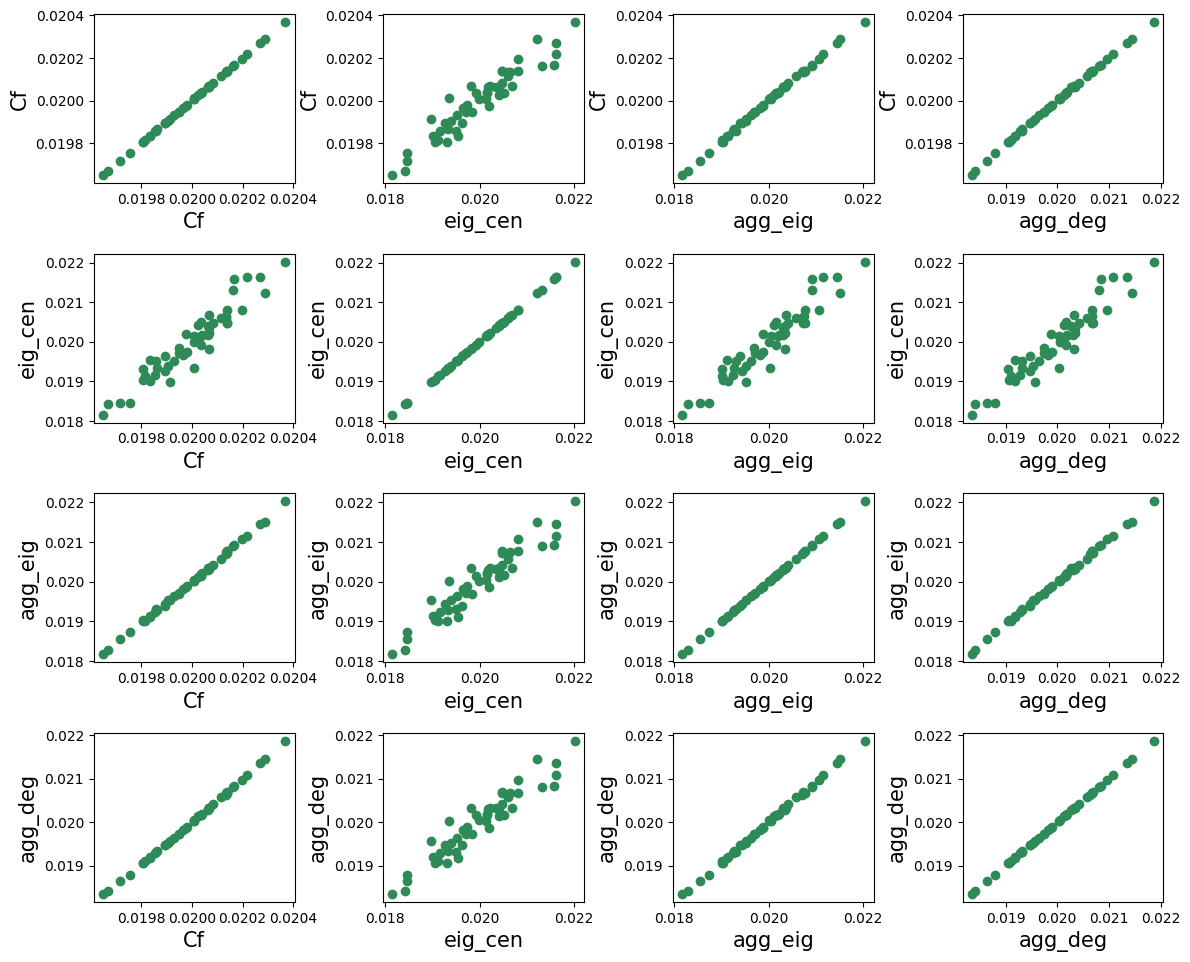

In [12]:
n = 50 # number of vertices
L = 50 # number of layers
k = 0.75 # number of zeros in each layer
tensor = generate_random_tensor(n, L, k) # random adjacency tensor

eig_cen_x = []
agg_deg_x = []
agg_eig_x = []
cf_x = []

# eig_cen
Q = make_q(n, L, tensor)
for i in range(n):
    eig_cen_x.append(eig_cen(Q, i))

# agg_deg
Q = make_agg(n, L, tensor)
for i in range(n):
    agg_deg_x.append(agg_deg(Q, i))

# agg_eig
for i in range(n):
    agg_eig_x.append(agg_eig(Q, i))


x0 = np.full(n, 1)
t0 = np.full(L, 1)
iter_count = 10
result_cf = cf(tensor, x0, t0, iter_count)

# cf (f-eigenvector centrality)
for i in range(n):
    cf_x.append(result_cf[0][i])

# scatter plot parameters
fig, axs = plt.subplots(4, 4, figsize=(12, 10))
plt.tight_layout(pad=3)
fsize = 15

arrays = [np.array(cf_x), np.array(eig_cen_x), np.array(agg_eig_x), np.array(agg_deg_x)]
names = ['Cf', 'eig_cen', 'agg_eig', 'agg_deg']

# make scatter plot
for i in range(len(arrays)):
    for j in range(len(arrays)):
        axs[i, j].scatter(arrays[j], arrays[i], color='seagreen')
        axs[i, j].set_xlabel(names[j], fontsize=fsize)
        axs[i, j].set_ylabel(names[i], fontsize=fsize)
plt.show()

# Влияние параметра $\alpha$

В статье даны оценки для минимального числа итераций, гарантирующих заданную точность. Именно эти оценки и дают функции ниже

In [13]:
def calculate_C(tensor, rho, beta):
    n, L = tensor.shape[1], tensor.shape[2]

    sum_A_ij_l = np.sum(tensor, axis=(1, 2))
    max_sum_A_ij_l = np.max(sum_A_ij_l)
    min_sum_A_ij_l = np.min(sum_A_ij_l)
    first = rho * np.log(max_sum_A_ij_l / min_sum_A_ij_l)

    sum_A_ij_l = np.sum(tensor, axis=(0, 1))
    max_sum_A_ij_l = np.max(sum_A_ij_l)
    min_sum_A_ij_l = np.min(sum_A_ij_l)
    second = (1 / beta) * np.log(max_sum_A_ij_l /  min_sum_A_ij_l)
    print(f'FIRST: {first} SECOND: {second}')
    C = first + second
    return C

def calculate_k(rho, C, eps):
  return int((np.log((1 - rho) * eps) - np.log(C)) / np.log(rho)) + 1


def calculate_rho(alpha, beta):
  return ((8 * alpha + beta)**0.5 + beta**0.5) / (2 * alpha * beta**0.5)


Функция calculate_C считает вспомогательную величину C, а calculate_k - минимальное число итераций, гарантирующих точность eps. Посмотрим как разные значения $\alpha$ влияют на итоговые рейтинги

# Графики

Время выполнения итерации 0: 0.000370 секунд
Среднее время одной итерации: 0.000370
FIRST: 0.35890591981782 SECOND: 0.06761796514212716
Время выполнения итерации 0: 0.000295 секунд
Время выполнения итерации 1: 0.000214 секунд
Время выполнения итерации 2: 0.000283 секунд
Время выполнения итерации 3: 0.000215 секунд
Время выполнения итерации 4: 0.000197 секунд
Время выполнения итерации 5: 0.000224 секунд
Время выполнения итерации 6: 0.000290 секунд
Время выполнения итерации 7: 0.000222 секунд
Время выполнения итерации 8: 0.000197 секунд
Время выполнения итерации 9: 0.000203 секунд
Время выполнения итерации 10: 0.000265 секунд
Время выполнения итерации 11: 0.000218 секунд
Время выполнения итерации 12: 0.000198 секунд
Время выполнения итерации 13: 0.000196 секунд
Время выполнения итерации 14: 0.000200 секунд
Время выполнения итерации 15: 0.000223 секунд
Время выполнения итерации 16: 0.000205 секунд
Время выполнения итерации 17: 0.000196 секунд
Время выполнения итерации 18: 0.000198 секунд


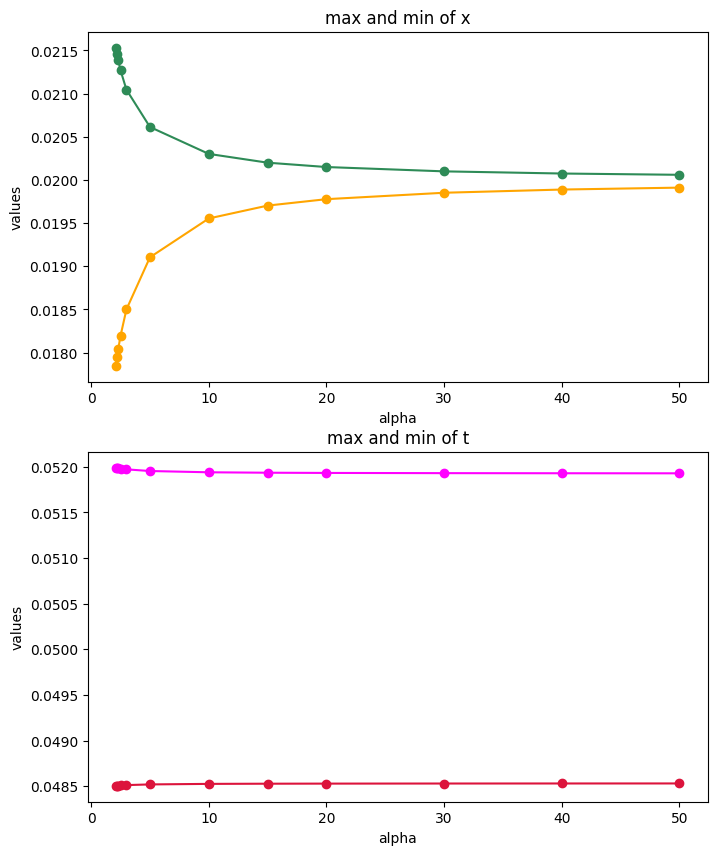

In [14]:
n = 50 # number of vertices
L = 20 # number of layers
k = 0.85 # number of zeros in each layer
tensor = generate_random_tensor(n, L, k)
eps = 0.00001
beta = 2
alphas = [2.1, 2.2, 2.3, 2.5, 3, 5, 10, 15, 20, 30, 40, 50]

x0 = np.full(n, 1)
t0 = np.full(L, 1)
result_cf = cf(tensor, x0, t0, 1)
max_ind = np.argmax(result_cf[0])
min_ind = np.argmin(result_cf[0])
max_ind_t = np.argmax(result_cf[1])
min_ind_t = np.argmin(result_cf[1])
max_x = []
min_x = []
max_t = []
min_t = []
iterations_count = []
for value in alphas:
    alpha = value
    rho = calculate_rho(alpha, beta)
    C = calculate_C(tensor, rho, beta)
    number = calculate_k(rho, C, eps)
    iterations_count.append(number)

    x0 = np.full(n, 1)
    t0 = np.full(L, 1)
    result_cf = cf(tensor, x0, t0, number)
    max_x.append(result_cf[0][max_ind])
    min_x.append(result_cf[0][min_ind])
    max_t.append(result_cf[1][max_ind_t])
    min_t.append(result_cf[1][min_ind_t])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

ax1.plot(alphas, max_x, marker='o', linestyle='-', color='seagreen')
ax1.plot(alphas, min_x, marker='o', linestyle='-', color='orange')
ax1.set_xlabel('alpha')
ax1.set_ylabel('values')
ax1.set_title('max and min of x')

ax2.plot(alphas, max_t, marker='o', linestyle='-', color='magenta')
ax2.plot(alphas, min_t, marker='o', linestyle='-', color='crimson')
ax2.set_xlabel('alpha')
ax2.set_ylabel('values')
ax2.set_title('max and min of t')

plt.show()

Видно, что рейтинги вершин сравниваются к одному значению при увеличении $\alpha$, но при этом сходимость заметно ускоряется, что показано на графике ниже.

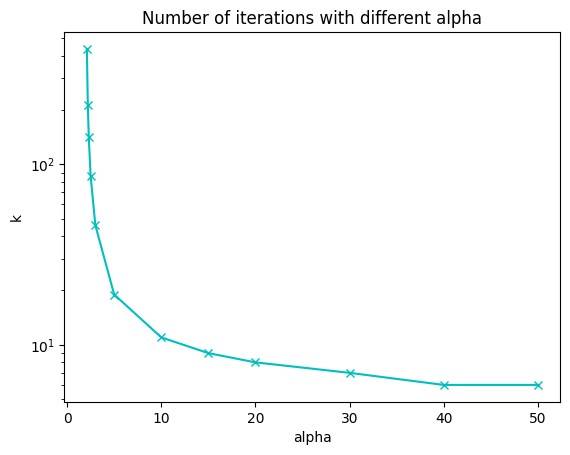

In [15]:
plt.plot(alphas, iterations_count, marker='x', linestyle='-', color='c')
plt.title('Number of iterations with different alpha')
plt.xlabel('alpha')
plt.ylabel('k')
plt.yscale('log')
plt.show()

# Анализ сингулярных чисел матриц развертки

Сингулярные числа заранее посчитаны и хранятся в файле "sv.txt" директории "data"

In [16]:
txt_file = 'sv.txt'

In [17]:
singular_values = []
with open(txt_file, "r") as f:
    lines = f.readlines()
    current_sv = []
    for line in lines:
        line = line.strip()
        if line.startswith("Mode-"):
            if current_sv:
                singular_values.append(np.array(current_sv))
                current_sv = []
        elif line:
            current_sv.extend([float(x) for x in line.split()])
    if current_sv:
        singular_values.append(np.array(current_sv))

for arr in singular_values:
  arr /= arr[0]


Посмотрим на полученные значения

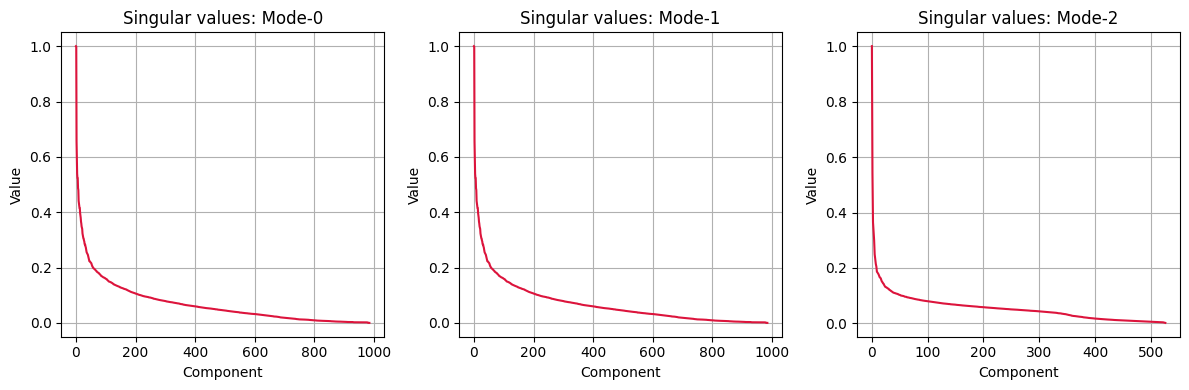

In [18]:
modes = ['Mode-0', 'Mode-1', 'Mode-2']
plt.figure(figsize=(12, 4))
for i, sv in enumerate(singular_values):
    plt.subplot(1, 3, i+1)
    plt.plot(sv, color='crimson')
    plt.title(f'Singular values: {modes[i]}')
    plt.xlabel('Component')
    plt.ylabel('Value')
    plt.grid(True)

plt.tight_layout()
plt.show()

# Использование разреженности

In [19]:
def f1_sparse(A_sparse, x, t, d=0.15):
    n = len(x)
    L = len(t)

    res = np.zeros(n)
    for l in range(L):
        Ax = A_sparse[l].dot(x)
        res += t[l] * Ax
    res *= (1 - d)

    sum_x = np.sum(x)
    sum_t = np.sum(t)
    res += (d / n) * sum_x * sum_t

    res = np.power(res, 1/alpha)
    res[np.isnan(res)] = 0
    return res


def f2_sparse(A_sparse, x, t, d=0.15):
    L = len(A_sparse)
    n = len(x)

    res = np.zeros(L)
    sum_x = np.sum(x)

    for l in range(L):
        Ax = A_sparse[l].dot(x)
        val = x.dot(Ax)

        res[l] = (1 - d) * val + (d / n) * (sum_x ** 2)

    res = np.power(res, 1/beta)
    res[np.isnan(res)] = 0
    return res


def g_sparse(A_sparse, x, t, d=0.15):
    f1_ = f1_sparse(A_sparse, x, t, d)
    f2_ = f2_sparse(A_sparse, x, t, d)

    f1_norm = np.linalg.norm(f1_, ord=1)
    f2_norm = np.linalg.norm(f2_, ord=1)

    if f1_norm == 0:
        f1_norm = 1
    if f2_norm == 0:
        f2_norm = 1

    return f1_ / f1_norm, f2_ / f2_norm


def calculate_C_sparse(tensor_sparse, rho, beta, d=0.15):
    L = len(tensor_sparse)
    n = tensor_sparse[0].shape[0]
    sum_i = np.zeros(n)
    for A in tensor_sparse:
        sum_i += np.array(A.sum(axis=1)).flatten()
    max_sum = np.max(sum_i) + d * L
    min_sum = np.min(sum_i) + d * L
    first = rho * np.log(max_sum / min_sum)
    sum_l = np.zeros(L)
    for l, A in enumerate(tensor_sparse):
        sum_l[l] = A.sum()
    max_sum = np.max(sum_l) + d * n
    min_sum = np.min(sum_l) + d * n
    second = (1 / beta) * np.log(max_sum / min_sum)
    C = first + second
    return C


def convert_to_sparse_tensor(tensor_dense):
    n, _, L = tensor_dense.shape
    tensor_sparse = []

    for l in range(L):
        sparse_matrix = sp.csr_matrix(tensor_dense[:, :, l])
        tensor_sparse.append(sparse_matrix)

    return tensor_sparse


real_iter = 0
def cf_sparse(A_sparse, x0, t0, k=5, x=0, t=0, eps=1e-6, display_time=False, d=0.15):
    global real_iter
    res = (x0, t0)
    real_iter = 0
    total_time = 0
    for i in range(k):
        start_time = time.time()
        res = g_sparse(A_sparse, res[0], res[1], d)
        end_time = time.time()
        execution_time = end_time - start_time
        total_time += execution_time
        real_iter += 1
    average_time = total_time / k
    if display_time:
        print(f"Среднее время одной итерации: {average_time:.6f}")
    return res

def cf_rank(tensor_sparse, alpha=2.5, beta=2, eps=1e-10):
    rho = calculate_rho(alpha, beta)
    C = calculate_C_sparse(tensor_sparse, rho, beta)
    iter_count = calculate_k(rho, C, eps)
    n = tensor_sparse[0].shape[0]
    L = len(tensor_sparse)
    #print(f"iter_count = {iter_count}")
    x0 = np.full(n, 1)
    t0 = np.full(L, 1)
    res = cf_sparse(tensor_sparse, x0, t0, iter_count, eps)
    return res


# Тепловая карта

Функция для построения тепловой карты рейтингов

In [20]:
def plot_heatmap(B, title='', log=False, cmap='plasma', fontsize=16):
    B = np.array(B, dtype=float)
    #B = B.transpose()
    if log:
        eps = 1e-10
        B = np.log(B + eps)
    plt.figure(figsize=(10, 8))
    plt.imshow(B, cmap=cmap, aspect='auto', origin='lower')
    plt.colorbar()
    plt.xlabel('t',fontsize=fontsize)
    plt.ylabel('x',fontsize=fontsize)
    plt.xticks(np.arange(0, B.shape[1] + 1, 10), fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.title(f'{title} centrality heatmap', fontsize=fontsize)
    plt.show()

# arXiv


Построение тензора по датасету цитирований. Файлы лежат в репозитории в папке "data"

In [21]:
edges_file = 'Cit-HepPh.txt'
dates_file = 'cit-HepPh-dates.txt'
dates = {}

dates={}
with open(dates_file) as f:
    for line in f:
        if line.startswith("#"): continue
        node,date=line.split()
        dates[int(node)]=datetime.strptime(date,"%Y-%m-%d")

min_date=min(dates.values())

def get_layer(date):
    delta=(date-min_date).days
    if delta<60: return 0
    else: return 1+(delta-60)//30

time_index={node:get_layer(d) for node,d in dates.items()}
L=max(time_index.values())+1

nodes=sorted(dates.keys())
node_to_idx={node:i for i,node in enumerate(nodes)}
N=len(nodes)

rows=[[] for _ in range(L)]
cols=[[] for _ in range(L)]

with open(edges_file) as f:
    for line in f:
        if line.startswith("#"): continue
        u,v=map(int,line.split())
        if u not in time_index or v not in node_to_idx: continue
        t=time_index[u]
        i=node_to_idx[u]
        j=node_to_idx[v]
        rows[t].append(i)
        cols[t].append(j)

tensor_sparse=[]
for l in range(L):
    r=rows[l]
    c=cols[l]
    if len(r)==0:
        A=sp.csr_matrix((N,N))
    else:
        data=np.ones(len(r))
        A=sp.csr_matrix((data,(r,c)),shape=(N,N))
    tensor_sparse.append(A)

print("Layers:",L)
print("Edges first layer:",tensor_sparse[0].nnz)

Layers: 122
Edges first layer: 3


Можно убедиться, что размеры тензора велики:

In [22]:
tensor_sparse[0].shape

(37621, 37621)

Количество временных слоев:

In [23]:
len(tensor_sparse)

122

In [24]:
alpha = 2.5
beta = 2
eps = 1e-10
start_time = time.time()
result_cf = cf_rank(tensor_sparse, alpha, beta, eps)
end_time = time.time()
execution_time = end_time - start_time
print(f"Время выполнения всего алгоритма: {execution_time:.6f} секунд")

Время выполнения всего алгоритма: 16.607160 секунд


Строим матрицу рейтингов:

In [25]:
x, t = result_cf
x = np.array(x)
t = np.array(t)
B = np.outer(x, t)

Считаем PageRank:

In [26]:
all_ranks = []
start_time = time.time()
for A in tensor_sparse:
    G = nx.from_scipy_sparse_array(A, create_using=nx.DiGraph)
    pr = nx.pagerank(G, alpha=0.85,  max_iter=1000)
    all_ranks.append(pr)
end_time = time.time()
execution_time = end_time - start_time
print(f"Время выполнения всего алгоритма: {execution_time:.6f} секунд")

Время выполнения всего алгоритма: 26.275396 секунд


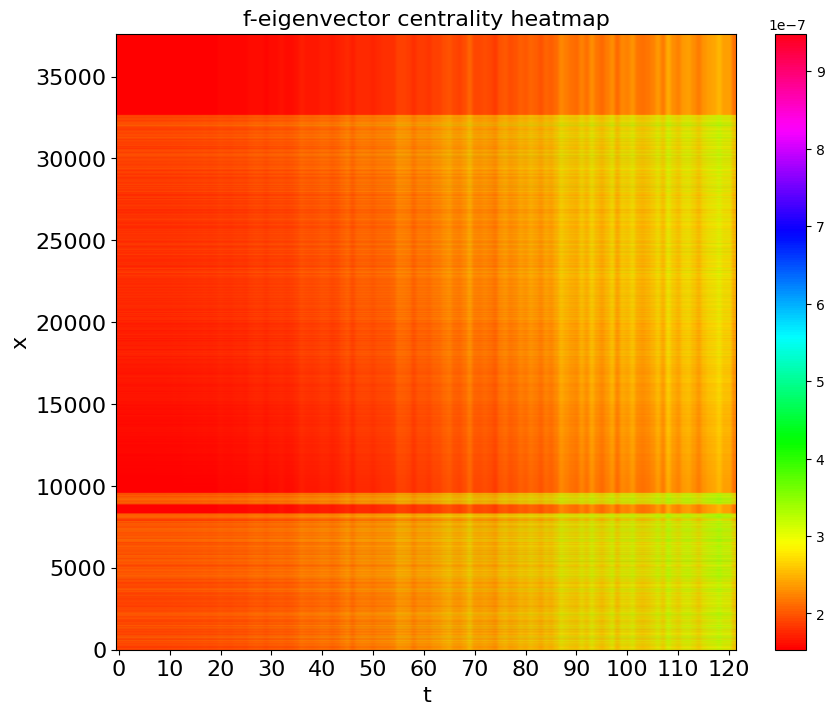

In [28]:
plot_heatmap(B, cmap='hsv', title='f-eigenvector')

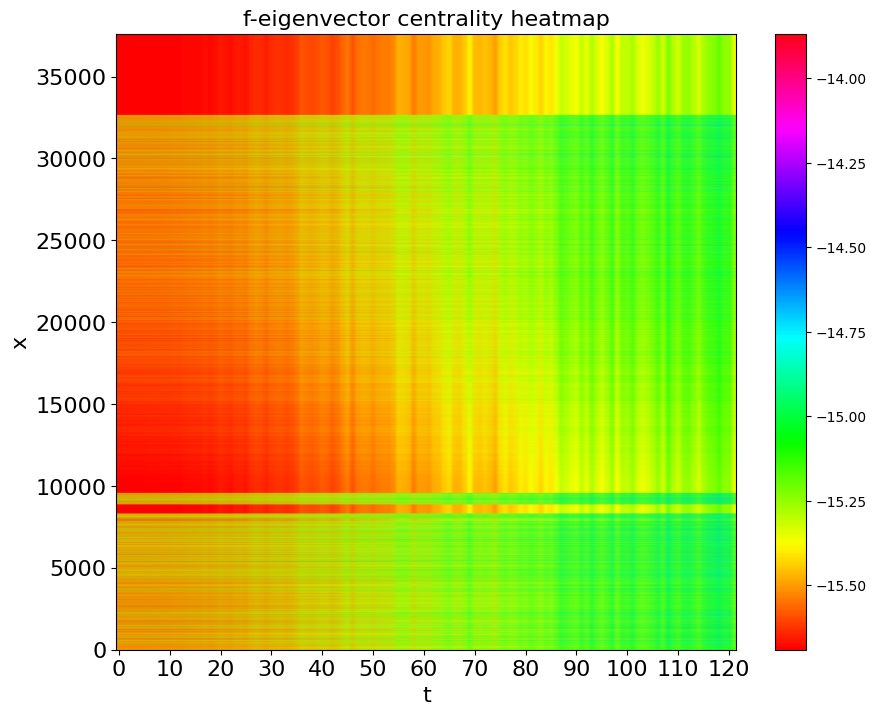

In [29]:
plot_heatmap(B, log=True, cmap='hsv', title='f-eigenvector')

# Отдельно по слоям

In [30]:
n1 = tensor_sparse[0].shape[0]
L1 = 1
d = 0.15
B1 = []

for i in range(L):
    A = [tensor_sparse[i]]
    C = calculate_C_sparse(A, rho, beta, d)
    iterations = calculate_k(rho, C, eps)
    x0 = np.full(n1, 1)
    t0 = np.full(L1, 1)
    res = cf_sparse(A, x0, t0, iterations, eps)
    B1.append(res[0])
B1 = np.array(B1)

In [34]:
count = 0
for i in B1:
  if np.linalg.norm(i) != 0:
    count += 1
v = B1[-6]

In [32]:
B1 = B1.transpose()

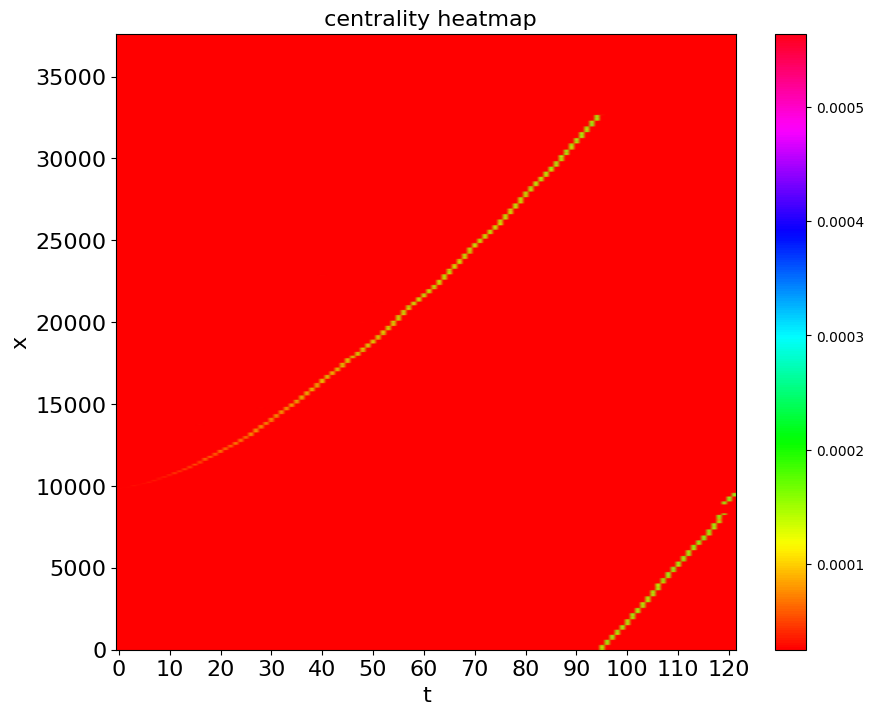

In [35]:
plot_heatmap(B1, log=False, cmap='hsv')

Видно, что динамика отсутствует, в отличие от классического применения алгоритма

# Пример PageRank

Модельный пример для демонстрации различий алгоритмов

In [37]:
def graph_from_edges(edges_, count=0):
    edges = edges_.copy()
    G = nx.DiGraph()
    nodes = list({u for u, v, w in edges} | {v for u, v, w in edges})
    for _ in range(count):
        event = random.randint(1, 5)
        if 1 <= event == 2: # Delete random edge
            i = random.randint(0, len(edges) - 1)
            edges.pop(i)
        elif 3 <= event == 4: # Create random edge
            x = random.sample(nodes, 2)
            result = any(t[:2] == [x[0], x[1]] for t in edges)
            while result:
                x = random.sample(nodes, 2)
                result = any(t[:2] == [x[0], x[1]] for t in edges)
            edges += [(x[0], x[1], w)]
        else: # change random weight
            i = random.randint(0, len(edges) - 1)
            t = edges[i]
            k = random.uniform(0, 2)
            edges[i] = (t[0], t[1], t[2] * k)
    G.add_weighted_edges_from(edges)
    return G


def graph_random_edit(G, count=1):

    for _ in range(count):
        event = random.randint(1, 5)
        # 🔹 1. удалить случайное ребро
        if event == 1 and G.number_of_edges() > 0:
            u, v = random.choice(list(G.edges()))
            G.remove_edge(u, v)

        # 🔹 2. добавить случайное ребро
        elif (event == 2 or event == 3) and G.number_of_nodes() >= 2:
            nodes = list(G.nodes())
            u, v = random.sample(nodes, 2)

            if not G.has_edge(u, v):
                w = random.uniform(1, 10)
                G.add_edge(u, v, weight=w)

        # 🔹 3. изменить вес ребра
        elif (event == 4 or event == 5) and G.number_of_edges() > 0:

            u, v = random.choice(list(G.edges()))
            old_w = G[u][v].get("weight", 1)
            k = random.uniform(0, 2)
            G[u][v]["weight"] = old_w * k
    return G


In [38]:
def get_color(node):
    if node == "B":
        return "crimson"
    elif node == "C":
        return "darkorange"
    elif node == "E":
        return "gold"
    elif node in ["D", "F"]:
        return "seagreen"
    elif node == "A":
        return "royalblue"
    else:
        return "darkorchid"


w = 1
edges = [
    ("D", "A", w),
    ("D", "B", w),
    ("C", "B", w),
    ("B", "C", w),
    ("F", "B", w),
    ("E", "B", w),
    ("E", "F", w),
    ("F", "E", w),
    ("E", "D", w),
    ("X1", "E", w),
    ("X2", "E", w),
    ("X3", "E", w),
    ("X4", "E", w),
    ("X5", "E", w),
    ("X1", "B", w),
    ("X2", "B", w),
    ("X3", "B", w),
]
G0 = graph_from_edges(edges)

Собираем все pagerank в каждый момент времени

In [39]:
G = graph_from_edges(edges)
nodes = sorted(G.nodes())
all_ranks = []
count = 101
tensor = []

start_time = time.time()
for _ in range(count):
    A = nx.to_scipy_sparse_array(G, nodelist=nodes, weight='weight', format='csr')
    tensor.append(A)
    pr = nx.pagerank(G, alpha=0.85,  max_iter=1000)
    all_ranks.append(pr)
    G = graph_random_edit(G)
end_time = time.time()
ex1 = end_time - start_time
ex1

1.788316249847412

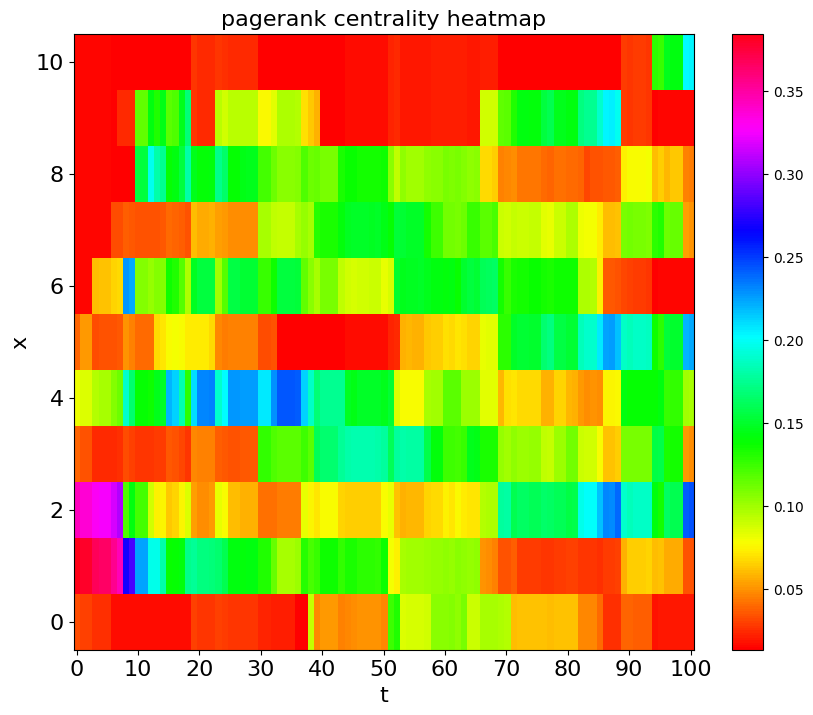

In [40]:
ranks_matrix = np.array([[pr[node] for node in nodes] for pr in all_ranks]).transpose()
plot_heatmap(ranks_matrix, log=False, cmap='hsv', title='pagerank')

Делаем cf

In [41]:
alpha = 2.5
beta = 2
eps = 1e-10

start_time = time.time()
result_cf = cf_rank(tensor, alpha, beta, eps)
end_time = time.time()
n = tensor[0].shape[0]
L = len(tensor)
ex2 = end_time - start_time
ex2

1.1018834114074707

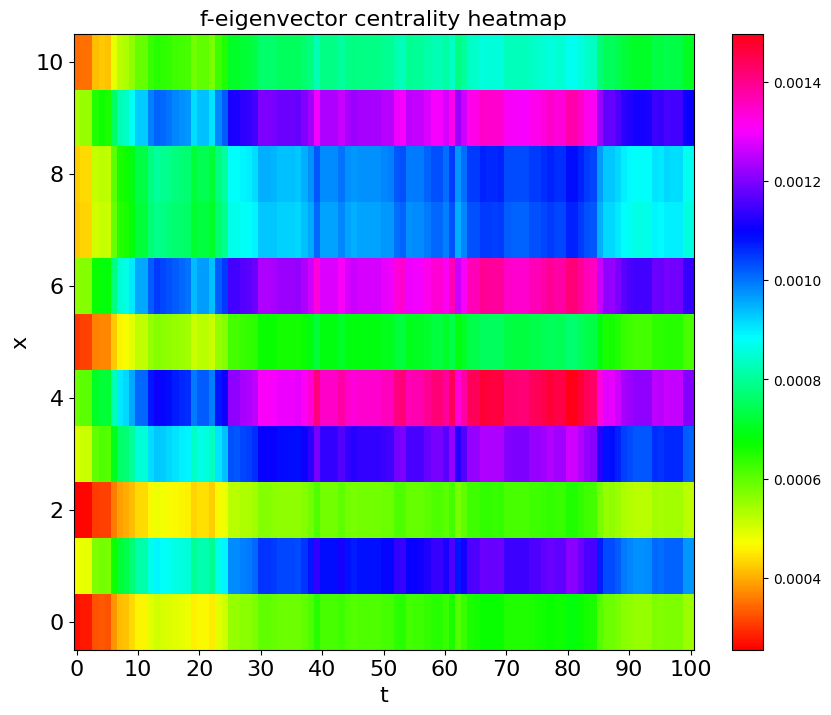

In [42]:
x, t = result_cf
B = np.outer(x, t)
plot_heatmap(B, log=False, cmap='hsv', title='f-eigenvector')

Видно, что в отличие от PageRank, рейтинги меняются плавно и непрерывно.

In [43]:
A_big = sp.block_diag(tensor, format='csr')

In [44]:
i = 10 # B

each_layer_pagerank = []
cf = []
combined_pagerank = []

G_big = nx.from_scipy_sparse_array(A_big, create_using=nx.DiGraph)
start_time = time.time()
pr_big = nx.pagerank(G_big, alpha=0.85)
end_time = time.time()
ex3 = end_time - start_time
print(ex3)
for t in range(L):
    each_layer_pagerank.append(all_ranks[t]['X5'])
    cf.append(result_cf[0][i] * result_cf[1][t] * 1e3)
    node_id = i + t * n
    combined_pagerank.append(pr_big[node_id] * 1e2)

cf = np.array(cf)
each_layer_pagerank = np.array(each_layer_pagerank)
combined_pagerank = np.array(combined_pagerank)

0.04451704025268555


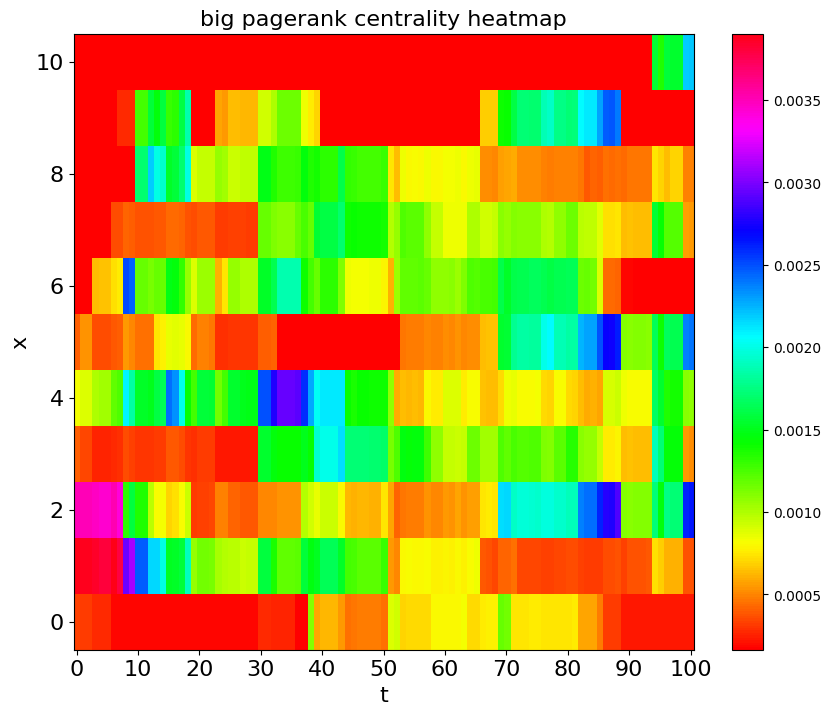

In [45]:
pr_big_matrix = np.array([
    [pr_big[t * n + j] for j in range(n)]
    for t in range(L)
]).transpose()
plot_heatmap(pr_big_matrix, log=False, cmap='hsv', title='big pagerank')

Тут, как и в обычном PageRank, рейтинги меняются скачками

Рассмотрим отдельную вершину:

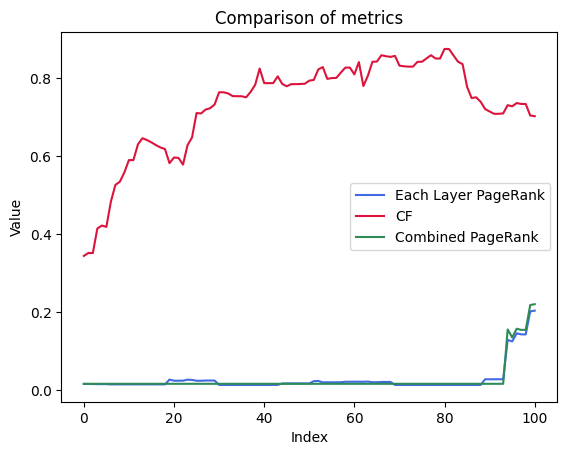

In [47]:
x = range(len(each_layer_pagerank))

plt.plot(x, each_layer_pagerank, label='Each Layer PageRank', color='royalblue')
plt.plot(x, cf, label='CF', color='crimson')
plt.plot(x, combined_pagerank, label='Combined PageRank', color='seagreen')

plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Comparison of metrics')
plt.legend()

plt.show()

# Визуализация

In [48]:
def visualize(G_, title='pagerank_graph'):
    pr = nx.pagerank(G_, alpha=0.85,  max_iter=1000)
    # создаём PyVis сеть
    net = Network(height="1000px", width="100%", directed=True)
    #coeffs = {"B": 75, "C": 75, "E": 100,"A": 125,  "D": 150,"F": 150, "X1": 250, "X2": 250, "X3": 250, "X4": 250, "X5": 250}
    coeff = 75

    # добавляем узлы
    for node in G_.nodes():
        net.add_node(
            node,
            label=f"{node}\n{pr[node]*100:.1f}%",
            size= coeff * pr[node],   # масштаб
            color=get_color(node)
        )

    # добавляем рёбра
    for u, v in G_.edges():
        net.add_edge(u, v)

    # физика (чтобы выглядело красиво)
    net.force_atlas_2based()
    net.toggle_physics(False)
    # сохраняем
    net.write_html(f"{title}.html")
    return

Создание html файлов с интерактивными графами в начальный и конечный момент времени:

In [52]:
visualize(G0, "start")
visualize(G, "end")

# Intersection similarity

Мера intersection similarity, использованная в работе

In [53]:
def intersection_similarity(list1, list2, K):
    sim = 0.0
    for k in range(1, K + 1):
        top1 = set(list1[:k])
        top2 = set(list2[:k])
        sym_diff = top1.symmetric_difference(top2)
        sim += len(sym_diff) / (2 * k)

    return sim / K

Считаем среднюю intersection similarity по результам многих экспериментов

In [54]:
exp_count = 100
avg_cf_pr = 0

K = len(G.nodes())

for exp in range(exp_count):

    G = graph_from_edges(edges)
    nodes = sorted(G.nodes())
    all_ranks = []
    tensor = []
    count = 101

    for _ in range(count):
        A = nx.to_scipy_sparse_array(G, nodelist=nodes, weight='weight', format='csr')
        tensor.append(A)
        pr = nx.pagerank(G, alpha=0.85, max_iter=1000)
        all_ranks.append(pr)
        G = graph_random_edit(G)

    result_cf = cf_rank(tensor, alpha, beta, eps)
    result_cf =  {nodes[i]: x[i] for i in range(len(G.nodes()))}
    mean_pr = {}
    for node in nodes:
        mean_pr[node] = np.mean([
            ranks[node] for ranks in all_ranks
        ])

    top_cf = sorted(
        result_cf,
        key=result_cf.get,
        reverse=True
    )
    top_mean_pr = sorted(
        mean_pr,
        key=mean_pr.get,
        reverse=True
    )
    sim_cf_pr = intersection_similarity(top_cf, top_mean_pr, K)
    avg_cf_pr += sim_cf_pr
avg_cf_pr /= exp_count

print("Average CF vs MeanPR :", avg_cf_pr)



Average CF vs MeanPR : 0.5569650072150073


Как и в тексте работы, получается около 0.5